# Построение модели поведенческого скоринга для прогнозирования просрочек на 90 дней

---

**Описание исследования**

Необходимо разработать модель поведенческого скоринга для действующего портфеля потребительских кредитов. В отличие от предкредитного скоринга, данная модель должна оценивать риск возникновения дефолта (просрочки более 90 дней) на основе актуального поведения клиента. Это позволит банку заблаговременно идентифицировать проблемных заёмщиков, оптимизировать объем резервов (ожидаемый прирост ликвидности 5–10%) и снизить регуляторные риски со стороны ЦБ. Задача классификации - предсказать вероятность дефолта на горизонте 12 месяцев.

---

**Цель исследования**

Разработать и обучить модель бинарной классификации для прогнозирования возникновения просрочки платежа длительностью 90+ дней в течение следующих 12 месяцев.

- Тип задачи: Бинарная классификация.

- Целевая переменная: Факт возникновения дефолта (1 - просрочка ≥90 дней в горизонте 12 месяцев, 0 - отсутствие такой просрочки).

- Особенности таргета: Используется метод скользящего окна с горизонтом H=12 месяцев.

- Ключевой вызов: Поиск оптимального порога классификации для баланса между объемом бизнеса и уровнем риска.

- Бизнес-метрики: 
    
    - Approval Rate: Доля клиентов, признанных моделью надежными.

    - Default Rate: Доля реальных дефолтов среди одобренных клиентов.

    - Missed Defaults Rate (1−Recall): Доля пропущенных дефолтов от общего числа плохих заемщиков.

---

**Задачи исследования**

- Анализ и подготовка данных: Изучение временной оси, обработка пропусков и корректное формирование целевой переменной по методу скользящего окна.

- EDA: Исследование признаков, описывающих финансовое поведение клиентов, и поиск ранних сигналов ухудшения платежной дисциплины.

- Построение моделей: Обучение ансамблей или градиентного бустинга для детекции скрытых паттернов дефолта.

- Оптимизация порога: Настройка порога вероятности для достижения целевых показателей по Approval Rate, Default Rate и Missed Defaults Rate.

- Валидация: Проверка устойчивости модели на тестовом временном отрезке и интерпретация наиболее значимых факторов риска для бизнеса.

---

**Описание данных**

Для построения модели поведенческого скоринга используется массив из 8 таблиц. Данные включают как статичную информацию на момент выдачи кредита, так и динамические показатели, меняющиеся во времени.

1. Основа для формирования выборки и таргета

    В этих таблицах заложена логика обучения: кого предсказываем и что именно.

    - Таблица 1 (ds_15_loan_payment_credit.csv): История просрочек. Содержит ID, дату начала и длительность просрочки в днях. Используется для разметки целевой переменной (был ли факт просрочки ≥90 дней в течение года после score_date).

    - Таблица 8 (ds_15_cohort_grid.csv): Реестр дат проведения скоринга. Содержит пары ID клиента и score_date. Это «точки отсчета», для которых нужно собрать признаки и предсказать риск на 12 месяцев вперед.

2. Динамические характеристики (Поведение)

    Данные, которые обновляются ежемесячно и отражают текущее состояние дел клиента.

    - Таблица 2 (ds_15_transactions.csv): Транзакционная активность. Помесячные траты по категориям:

        - MCC_5411, 5300, 5722: Продукты, маркетплейсы, техника.

        - MCC_5814, 5812, 3990: Фастфуд, рестораны, сервисы Яндекса.

        - MCC_4900: Коммунальные платежи (ЖКУ).

    - Таблица 6 (ds_15_credit_rating.csv): Внешний кредитный рейтинг клиента на конкретные даты. Позволяет отследить, как менялась оценка надежности заемщика со стороны.

3. Социально-демографический и кредитный профиль

    Статичные или редко меняющиеся данные о заемщике.

    - Таблица 3 (ds_15_client_description.csv): Личные данные клиента (возраст, семейное положение, наличие иждивенцев) и дата, когда клиент начал пользоваться услугами банка.

    - Таблица 4 (ds_15_credit_description.csv): Финансовые условия на старте: заявленный доход и общая сумма кредита.

    - Таблица 5 (ds_15_mortgage_presence.csv): Сведения об ипотеке (наличие флага и дата открытия). Ипотека - это долгосрочный якорь, сильно влияющий на платежную дисциплину.

4. Внешние факторы

    - Таблица 7 (ds_15_macro_data.csv): Макроэкономические показатели (инфляция, безработица, ключевая ставка). Помогают модели понять, вызваны ли просрочки личными проблемами клиента или общим кризисом в стране.

---

## Перевод бизнес-задачи на язык машинного обучения

Методы и модели

- Модели: В качестве Baseline используем логистическую регрессию. Основной стек: деревья решений и бэггинг (RandomForest).

- Работа с данными: Агрегация транзакций по месяцам, создание временных лагов для кредитного рейтинга и макропоказателей.

- Threshold Tuning: Ключевой этап решения - подбор порога классификации для баланса метрик.

План решения

- Формирование витрины: Сборка всех 8 таблиц в единый датасет на основе сетки дат скоринга.

- Разметка: Расчет таргета методом скользящего окна.

- Обучение и валидация: Кросс-валидация и подбор гиперпараметров (Optuna).

- Бизнес-оптимизация: Выбор порога отсечения, удовлетворяющего требованиям банка по уровню риска.


## Загрузка необходимых библиотек

In [ ]:
from pathlib import Path

req_path = Path("../../requirements.txt")
if req_path.exists():
    %pip install -qr {req_path}
else:
    %pip install -qU --force-reinstall "numpy<2.2.0" "pillow<12.0" pandas==2.2.2 numba scipy scikit-learn imbalanced-learn matplotlib seaborn phik joblib category_encoders optuna mlxtend

In [2]:
import joblib
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import optuna

from mlxtend.evaluate.time_series import GroupTimeSeriesSplit

import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold, RFE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, roc_curve, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)

In [3]:
RANDOM_STATE = 42

## Загрузка данных

In [5]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive монтирован")
except ImportError:
    print("Локальное использование")

Mounted at /content/drive
Google Drive монтирован


In [35]:
def get_df(file_name):
    local_path = Path(f'/content/drive/MyDrive/datasets/{file_name}')
    yp_path = Path(f'/datasets/{file_name}')

    if local_path.exists():
        df = pd.read_csv(local_path, sep=',', decimal='.')
    elif yp_path.exists():
        df = pd.read_csv(yp_path, sep=',', decimal='.')
    else:
        raise "Путь до датасета неверный"

    int_cols = df.select_dtypes(include=['integer']).columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    float_cols = df.select_dtypes(include=['float']).columns
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')

    print('-' * 70)
    print(file_name)
    display(df.head())
    df.info()

    return df

loan_payment_credit = get_df('ds_15_loan_payment_credit.csv')
transactions = get_df('ds_15_transactions.csv')
client_description = get_df('ds_15_client_description.csv')
credit_description = get_df('ds_15_credit_description.csv')
mortgage_presence = get_df('ds_15_mortgage_presence.csv')
credit_rating = get_df('ds_15_credit_rating.csv')
macro_data = get_df('ds_15_macro_data.csv')
cohort_grid = get_df('ds_15_cohort_grid.csv')

----------------------------------------------------------------------
ds_15_loan_payment_credit.csv


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int16 
dtypes: int16(1), object(2)
memory usage: 96.8+ KB
----------------------------------------------------------------------
ds_15_transactions.csv


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.760010,2156.67,1519.46,4352.90


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  object 
 1   date        577494 non-null  object 
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float32
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float32(1), float64(7), object(2)
memory usage: 41.9+ MB
----------------------------------------------------------------------
ds_15_client_description.csv


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ID                 577494 non-null  object
 1   date               577494 non-null  object
 2   кредитный_рейтинг  577494 non-null  int16 
dtypes: int16(1), object(2)
memory usage: 9.9+ MB
----------------------------------------------------------------------
ds_15_macro_data.csv


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     object 
 1   учетная_ставка       84 non-null     float32
 2   уровень_безработицы  84 non-null     float32
 3   инфляция             84 non-null     float32
dtypes: float32(3), object(1)
memory usage: 1.8+ KB
----------------------------------------------------------------------
ds_15_cohort_grid.csv


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB


Предоставленный массив данных содержит 8 таблиц, охватывающих 13 500 клиентов и более 577 тысяч ежемесячных записей об их активности. Структура данных позволяет объединить статичные профили заемщиков (возраст, доход, семейное положение) с динамическими факторами: транзакциями по 8 категориям MCC-кодов, изменениями кредитного рейтинга и макроэкономическим контекстом. Объем целевых событий (5 500 записей о просрочках) достаточен для обучения моделей, а наличие ипотечных данных у половины базы и временной сетки скоринга дает возможность построить качественную поведенческую модель с использованием временных лагов.

## Исследовательский анализ данных

In [9]:
def show_features(df: pd.DataFrame):
    table = []
    
    num_cols, cat_cols = [], []
    for col in df.columns:
        nunique = df[col].nunique()
        if nunique > 10:
            num_cols.append(col)
        else:
            cat_cols.append(col)
        
        table.append({
            'Признак': col,
            'Уникальные значения': df[col].unique(),
            'Кол-во': nunique,
        })

    display(pd.DataFrame(table).sort_values('Кол-во', ascending=False))
    
    return num_cols, cat_cols

In [10]:
def create_num_plot(data, col):
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 2))
    
    hist = axes[0]
    data.plot(
        kind='hist',
        bins=70,
        grid=True,
        ax=hist
    )
    hist.set_title(f'Распределение: {col}', fontsize=12)
    hist.set_xlabel('Значение')
    hist.set_ylabel('Количество (log)')
    hist.set_yscale('log')
    
    box = axes[1]
    sns.boxplot(
        data=data,
        ax=box
    )
    box.set_title(f'Размах: {col}', fontsize=12)
    box.set_ylabel('Значение')
    box.grid(True)
    box.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    plt.close()

def show_num_plots(df, cols):
    for col in cols:
        create_num_plot(df[col], col)

In [11]:
def create_cat_plot(df, col):
    plt.figure(figsize=(12, 2)) 
    
    ax = sns.countplot(
        x=col,
        data=df,
        hue=col, 
        legend=False,
        palette='viridis', 
        dodge=False,
    )
    
    plt.title(f'Распределение: {col}', fontsize=12)
    plt.xlabel('Значение')
    plt.ylabel('Количество')

    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=1)

    plt.tight_layout()
    plt.show()
    plt.close()
    
def show_cat_plots(df, cols):
    for col in cols:
        create_cat_plot(df, col)

In [12]:
def show_missing_stats(df):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isna().sum(),
        'Доля пропусков': df.isna().mean() * 100
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return missing_stats \
            .sort_values(by='Кол-во пропусков', ascending=False) \
            .style.format({'Доля пропусков': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm')

In [13]:
def primary_analysis(df: pd.DataFrame, name):
    display(Markdown(f'### Анализ датафрейма: **{name}**'))
    
    display(Markdown(f'#### пропуски'))
    display(show_missing_stats(df))
    
    display(Markdown(f'#### дубликаты'))
    print("Явные дубликаты строк:", df.duplicated().sum())

    display(Markdown(f'#### числовые признаки'))
    num_df = df.select_dtypes(include=['number'])
    if not num_df.empty:
        display(num_df.describe())
        num_cols, cat_cols = show_features(num_df)
        
        if len(num_cols) > 0:
            show_num_plots(num_df, num_cols)

        if len(cat_cols) > 0:
            show_cat_plots(num_df, cat_cols)
    else:
        print('Отсутствуют')
            

    print()

    display(Markdown(f'#### категориальные признаки'))
    cat_df = df.select_dtypes(include=['object'])
    if not cat_df.empty:
        display(cat_df.describe())
        _, cat_cols = show_features(cat_df)

        if len(cat_cols) > 0:
            show_cat_plots(cat_df, cat_cols)
    else:
        print('Отсутствуют')
        
    print('-' * 70)

### Анализ датафрейма: **кредитный платеж**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,просрочка_дней
count,5500.000000
mean,114.748000
std,20.362422
min,80.000000
25%,97.000000
50%,115.000000
75%,132.000000
max,150.000000


,Признак,Уникальные значения,Кол-во
0,просрочка_дней,"[120, 121, 87, 109, 84, 83, 101, 112, 105, 146...",71


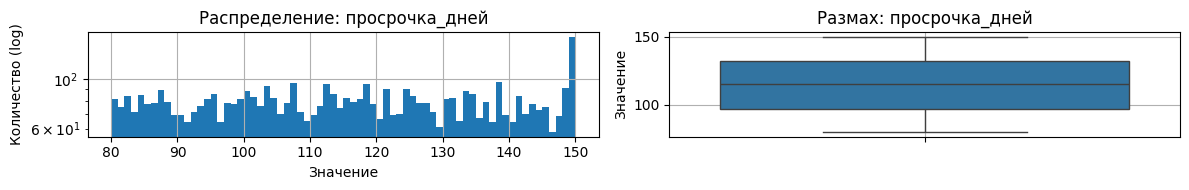

#### категориальные признаки

,ID,дата_начала_периода
count,5500,5500
unique,5500,73
top,IDF54902735,2018-12-01
freq,1,209


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54995533, IDF54964538, IDF550...",5500
1,дата_начала_периода,"[2014-12-01, 2015-06-01, 2018-03-01, 2019-09-0...",73


----------------------------------------------------------------------


### Анализ датафрейма: **транзакции**

...

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
count,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000
mean,6177.123479,3507.682295,2993.862550,9263.099506,1128.116577,3604.437043,3682.487182,5414.896895
std,8835.871514,5710.755226,4541.119582,12299.732992,1557.049316,5005.896972,5567.979383,7190.882383
min,162.910000,62.180000,67.060000,286.110000,31.900000,108.400000,81.290000,166.260000
25%,1360.880000,583.480000,611.540000,2139.480000,245.059998,824.942500,700.632500,1250.850000
50%,2659.590000,1233.110000,1224.530000,4115.385000,476.890015,1590.120000,1397.065000,2398.330000
75%,6561.467500,3642.392500,3201.612500,9287.545000,1159.520020,3866.050000,3872.412500,5413.530000
max,86939.400000,55720.690000,47969.570000,101301.950000,14261.490234,54630.190000,52987.530000,60033.550000


,Признак,Уникальные значения,Кол-во
3,MCC_5411,"[5711.1, 5824.65, 5209.51, 5765.96, 5632.11, 7...",462655
0,MCC_5300,"[3267.59, 3196.58, 3550.54, 3385.98, 3214.84, ...",423534
7,MCC_другое,"[3657.35, 3322.61, 3467.06, 3354.44, 4352.9, 5...",406485
5,MCC_5722,"[2374.78, 2187.11, 2076.54, 2231.77, 2156.67, ...",359405
6,MCC_4900,"[4059.86, 4592.26, 3605.25, 2209.39, 1519.46, ...",353656
1,MCC_5814,"[1282.11, 2443.37, 4277.72, 4530.63, 4146.65, ...",345459
2,MCC_5812,"[1457.96, 1334.2, 1463.75, 1261.4, 1405.15, 23...",335475
4,MCC_3990,"[647.43, 1067.55, 1167.95, 986.99, 640.76, 633...",221493


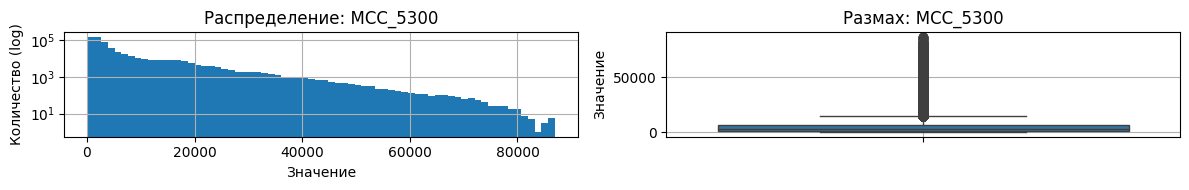

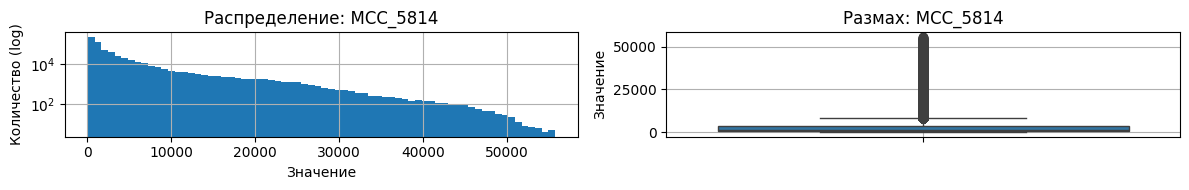

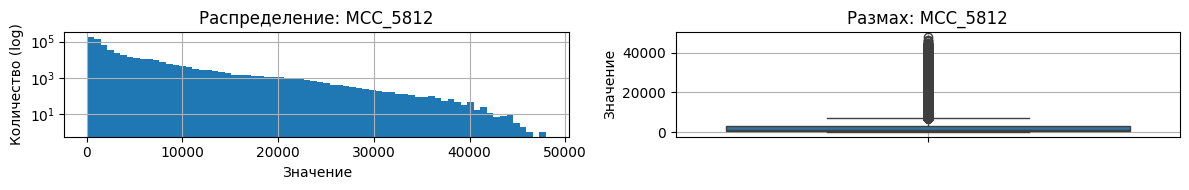

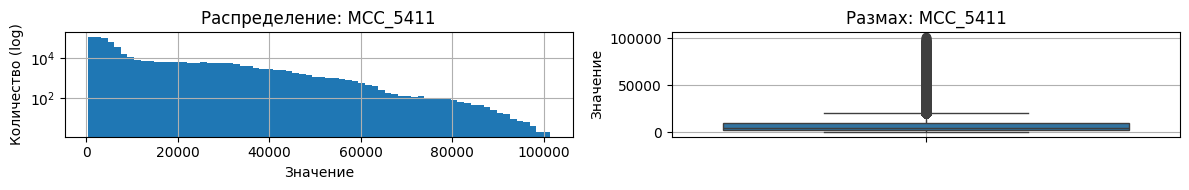

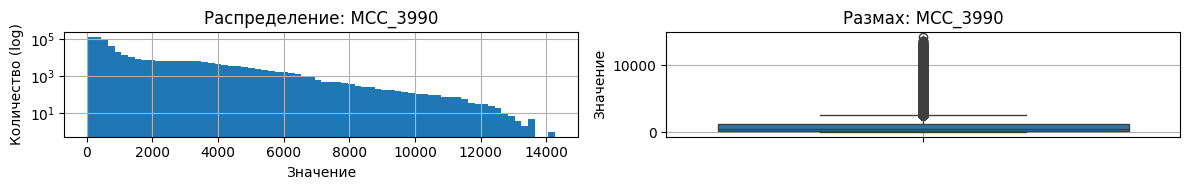

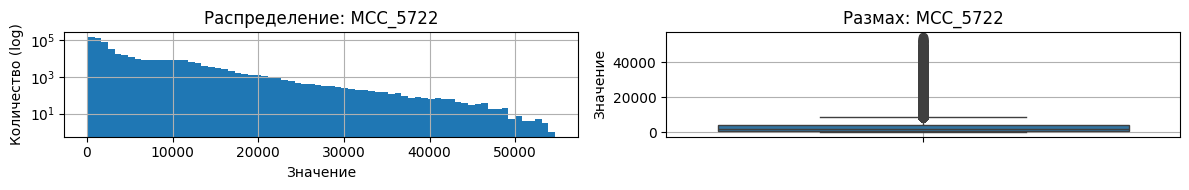

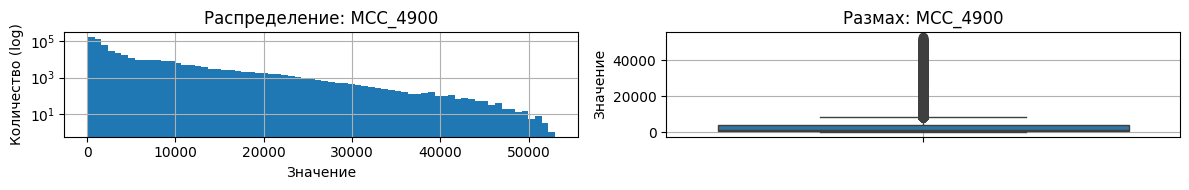

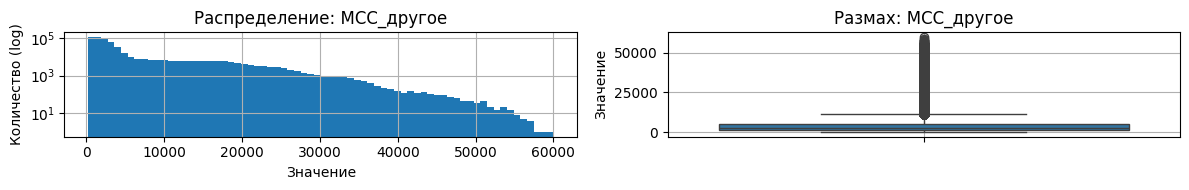

#### категориальные признаки

,ID,date
count,577494,577494
unique,13500,84
top,IDF54905698,2019-12-01
freq,84,13500


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
1,date,"[2013-05-01, 2013-06-01, 2013-07-01, 2013-08-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **описание клиента**

...

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,возраст,наличие_иждивенцев
count,13500.000000,13500.000000
mean,41.304815,0.484741
std,15.096673,0.499786
min,18.000000,0.000000
25%,28.000000,0.000000
50%,40.000000,0.000000
75%,54.000000,1.000000
max,69.000000,1.000000


,Признак,Уникальные значения,Кол-во
0,возраст,"[41, 45, 34, 40, 66, 57, 18, 27, 25, 32, 23, 5...",52
1,наличие_иждивенцев,"[1, 0]",2


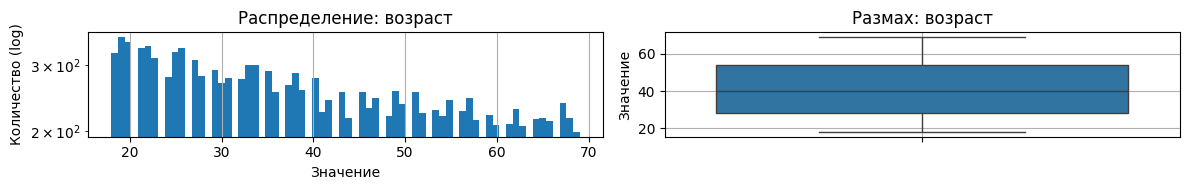

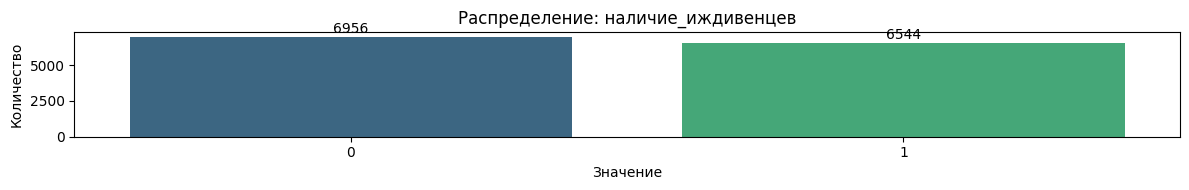

#### категориальные признаки

,ID,семейное_положение,дата_регистрации
count,13500,13500,13500
unique,13500,3,84
top,IDF55140157,нет семьи,2014-03-01
freq,1,4584,189


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
2,дата_регистрации,"[2013-05-01, 2017-12-01, 2013-11-01, 2018-08-0...",84
1,семейное_положение,"[разведённые, нет семьи, есть семья]",3


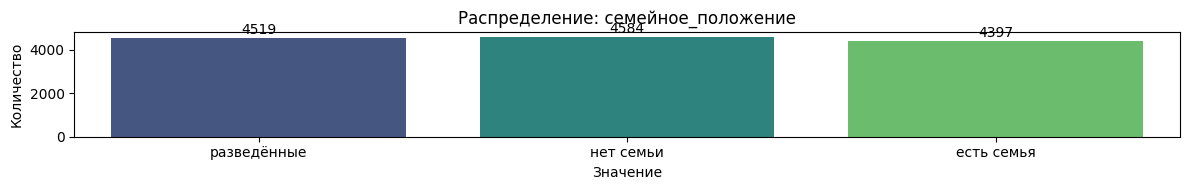

----------------------------------------------------------------------


### Анализ датафрейма: **описание кредита**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,доход,сумма_кредита
count,13500.000000,1.350000e+04
mean,79089.268593,1.993383e+06
std,40045.549462,1.061381e+06
min,15010.000000,7.500000e+04
25%,43347.000000,1.079329e+06
50%,77991.500000,2.032732e+06
75%,113615.500000,2.919236e+06
max,149988.000000,3.749400e+06


,Признак,Уникальные значения,Кол-во
1,сумма_кредита,"[1960785, 3375810, 401700, 1952655, 1107870, 3...",13140
0,доход,"[27035, 64502, 90477, 133475, 51324, 50694, 12...",12801


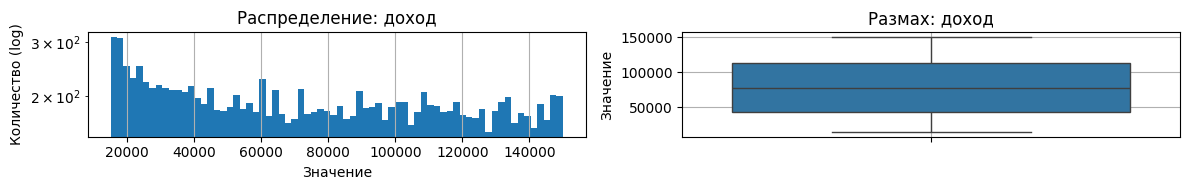

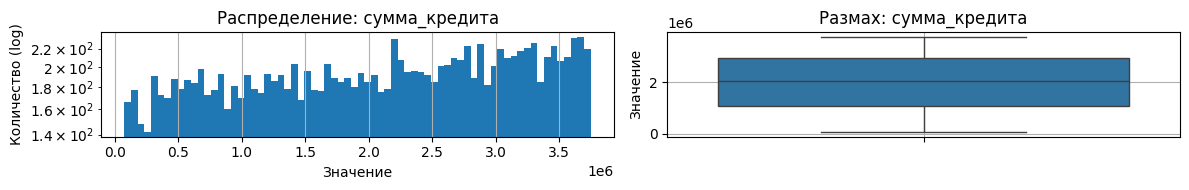

#### категориальные признаки

,ID
count,13500
unique,13500
top,IDF55140157
freq,1


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500


----------------------------------------------------------------------


### Анализ датафрейма: **наличие ипотеки**

...

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,наличие_ипотеки
count,6609.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


,Признак,Уникальные значения,Кол-во
0,наличие_ипотеки,[1],1


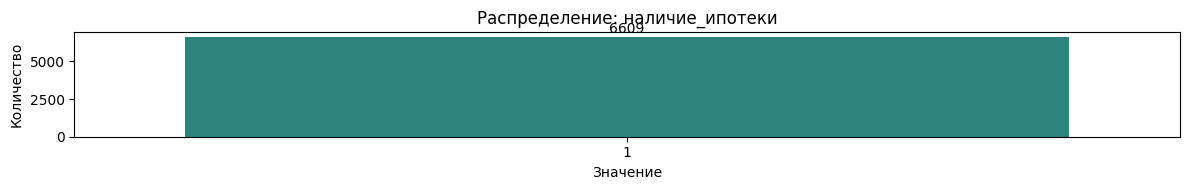

#### категориальные признаки

,ID,дата_открытия
count,6609,6609
unique,6609,84
top,IDF55151634,2018-12-01
freq,1,98


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF54896351, IDF54896367, IDF54896414, IDF548...",6609
1,дата_открытия,"[2013-03-01, 2018-01-01, 2018-02-01, 2019-02-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **кредитный рейтинг**

...

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,кредитный_рейтинг
count,577494.000000
mean,603.190961
std,64.358896
min,343.000000
25%,558.000000
50%,600.000000
75%,646.000000
max,900.000000


,Признак,Уникальные значения,Кол-во
0,кредитный_рейтинг,"[692, 688, 666, 669, 658, 656, 655, 668, 663, ...",510


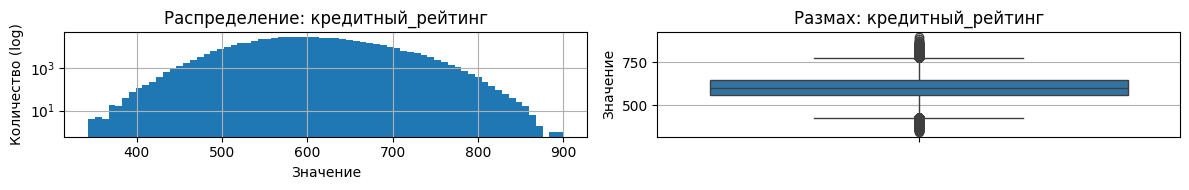

#### категориальные признаки

,ID,date
count,577494,577494
unique,13500,84
top,IDF54905698,2019-12-01
freq,84,13500


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
1,date,"[2013-05-01, 2013-06-01, 2013-07-01, 2013-08-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **макроданные**

...

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,учетная_ставка,уровень_безработицы,инфляция
count,84.000000,84.000000,84.000000
mean,8.638517,5.175000,0.527500
std,2.466112,0.409488,0.570189
min,5.500000,4.300000,-0.540000
25%,7.250000,4.900000,0.262500
50%,7.750000,5.200000,0.425000
75%,10.329545,5.500000,0.635000
max,17.000000,6.000000,3.850000


,Признак,Уникальные значения,Кол-во
2,инфляция,"[0.97, 0.56, 0.34, 0.51, 0.66, 0.42, 0.82, 0.1...",62
0,учетная_ставка,"[5.5, 7.0, 7.068182, 7.5, 7.5869565, 8.0, 9.5,...",40
1,уровень_безработицы,"[5.7, 5.8, 5.9, 5.5, 5.4, 5.3, 5.2, 5.1, 5.6, ...",18


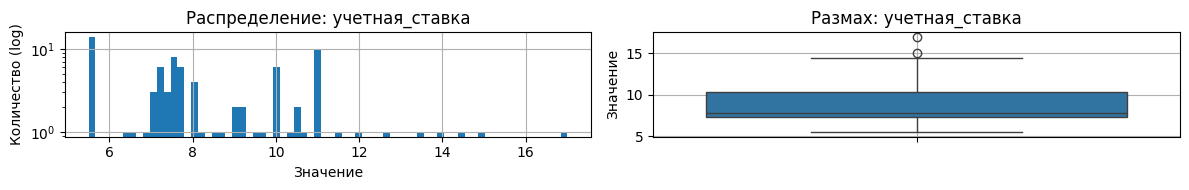

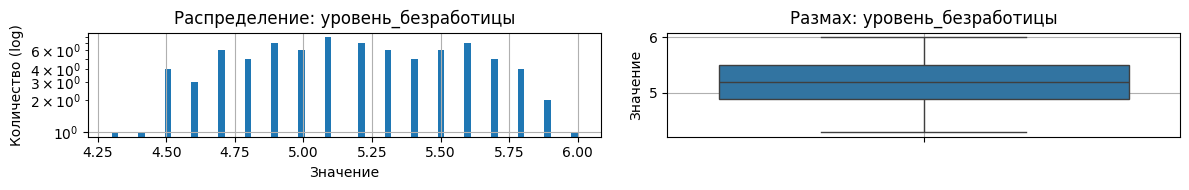

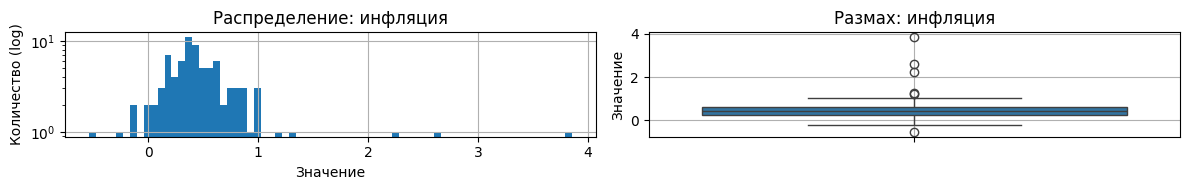

#### категориальные признаки

,date
count,84
unique,84
top,2013-01-01
freq,1


,Признак,Уникальные значения,Кол-во
0,date,"[2013-01-01, 2013-02-01, 2013-03-01, 2013-04-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **когортная сетка**

...

Отсутствуют



#### категориальные признаки

,ID,score_date
count,577494,577494
unique,13500,84
top,IDF54905698,2019-12-01
freq,84,13500


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
1,score_date,"[2013-05-01, 2013-06-01, 2013-07-01, 2013-08-0...",84


----------------------------------------------------------------------


In [14]:
tables = [
    (loan_payment_credit, 'кредитный платеж'),
    (transactions, 'транзакции'),
    (client_description, 'описание клиента'),
    (credit_description, 'описание кредита'),
    (mortgage_presence, 'наличие ипотеки'),
    (credit_rating, 'кредитный рейтинг'),
    (macro_data, 'макроданные'),
    (cohort_grid, 'когортная сетка')
]

for table, name in tables:
    primary_analysis(table, name)

Вывод: технические пропуски и явные дубликаты отсутствуют во всех таблицах. Выборка включает 13 500 уникальных клиентов с равномерным распределением по возрасту (от 18 до 69 лет) и семейному статусу, при этом около 49% из них (6609 человек) имеют ипотеку. Когортная сетка подтверждает полную структуру временных рядов: для каждого из 13 500 id представлено ровно 84 ежемесячных наблюдения, что формирует массив из 577 494 записей для анализа динамики транзакций и рейтинга. В транзакционных данных по всем MCC-кодам выявлены экстремальные правосторонние выбросы (максимумы до 101 тыс. при средних значениях 6–9 тыс.), в то время как кредитный рейтинг (от 343 до 900) распределен нормально. Целевые события дефолта (5500 записей) зафиксированы строго в интервале просрочки от 80 до 150 дней, а макроэкономический фон за 7 лет отражает существенные колебания учетной ставки от 5,5% до 17%, и периоды инфляции до 4%, и дефляции (-0.54%), колебания безработицы в пределах 4,3–6,0%, так что модель сможет учесть влияние кризисов на платежеспособность.

## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. Признаки можно присоединять к когорте только по информации, рассчитанной на даты строго меньше `score_date`. Это связано с тем, что поведенческие признаки допустимо брать только за прошлый относительно даты скоринга период. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущий период относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. - используем;
>* транзакции за ноябрь 2023 г. - используем;
>* макроэкономические показатели за декабрь 2023 г. - используем;
>* транзакции 16 января 2024 г. - **не** используем.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендация: не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.

Сделайте выводы о получившейся таблице.

In [56]:
id = 'IDF54980124'

display(loan_payment_credit[loan_payment_credit['ID'] == id])
display(transactions[transactions['ID'] == id])
display(client_description[client_description['ID'] == id])
display(credit_description[credit_description['ID'] == id])
display(mortgage_presence[mortgage_presence['ID'] == id])
display(credit_rating[credit_rating['ID'] == id].shift(1))
display(cohort_grid[cohort_grid['ID'] == id])

,ID,дата_начала_периода,просрочка_дней


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
221254,IDF54980124,2016-11-01,3562.06,1315.99,1453.03,6277.69,655.099976,2383.43,4345.00,3860.06
221255,IDF54980124,2016-12-01,3809.28,3130.50,1550.66,6364.93,1155.319946,2543.82,4871.62,4110.81
221256,IDF54980124,2017-01-01,3670.42,5316.52,1568.36,6492.63,1197.569946,2338.20,4595.35,4024.18
221257,IDF54980124,2017-02-01,3433.09,5356.15,1558.29,6295.74,1179.500000,2213.85,2866.88,3776.43
221258,IDF54980124,2017-03-01,4021.73,5165.24,1616.39,7091.90,697.309998,2698.65,2138.34,5313.72
221259,IDF54980124,2017-04-01,4308.60,3678.92,2983.93,10111.61,806.260010,2727.40,1955.66,6947.88
221260,IDF54980124,2017-05-01,5342.21,1541.85,4721.11,10500.00,716.210022,2871.42,2131.81,5499.87
221261,IDF54980124,2017-06-01,8736.06,1498.09,5321.49,9804.52,862.650024,2767.18,2036.96,4131.39
221262,IDF54980124,2017-07-01,10177.55,1426.40,4873.38,7055.75,865.570007,2810.38,2133.73,4588.89
221263,IDF54980124,2017-08-01,8094.26,1638.86,2964.24,7394.17,869.679993,3386.43,2239.60,4235.55


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
5174,IDF54980124,39,разведённые,0,2016-11-01


,ID,доход,сумма_кредита
5174,IDF54980124,31024,1074345


,ID,дата_открытия,наличие_ипотеки
2172,IDF54980124,2016-11-01,1


,ID,date,кредитный_рейтинг
221254,None,NaT,NaN
221255,IDF54980124,2016-11-01,650.0
221256,IDF54980124,2016-12-01,659.0
221257,IDF54980124,2017-01-01,672.0
221258,IDF54980124,2017-02-01,685.0
221259,IDF54980124,2017-03-01,667.0
221260,IDF54980124,2017-04-01,656.0
221261,IDF54980124,2017-05-01,659.0
221262,IDF54980124,2017-06-01,646.0
221263,IDF54980124,2017-07-01,657.0


,ID,score_date
221254,IDF54980124,2016-11-01
221255,IDF54980124,2016-12-01
221256,IDF54980124,2017-01-01
221257,IDF54980124,2017-02-01
221258,IDF54980124,2017-03-01
221259,IDF54980124,2017-04-01
221260,IDF54980124,2017-05-01
221261,IDF54980124,2017-06-01
221262,IDF54980124,2017-07-01
221263,IDF54980124,2017-08-01


In [63]:
cohort_grid['score_date'] = pd.to_datetime(cohort_grid['score_date'])
loan_payment_credit['дата_начала_периода'] = pd.to_datetime(loan_payment_credit['дата_начала_периода'])
client_description['дата_регистрации'] = pd.to_datetime(client_description['дата_регистрации'])
mortgage_presence['дата_открытия'] = pd.to_datetime(mortgage_presence['дата_открытия'])
macro_data['date'] = pd.to_datetime(macro_data['date'])
transactions['date'] = pd.to_datetime(transactions['date'])
credit_rating['date'] = pd.to_datetime(credit_rating['date']) 

first_defaults = (
    loan_payment_credit[loan_payment_credit['просрочка_дней'] >= 90]
    .sort_values(["ID", "дата_начала_периода"])
    .drop_duplicates("ID", keep="first")
    [['ID', 'дата_начала_периода']]
)

df = pd.merge(cohort_grid, first_defaults, on='ID', how='left')

df['target'] = (
    df['дата_начала_периода'].notna() & 
    (df['дата_начала_периода'] >= df['score_date']) & 
    (df['дата_начала_периода'] < df['score_date'] + pd.Timedelta(days=365))
).astype(int)

df = df[~(df['дата_начала_периода'] < df['score_date'])].copy()

for tbl in [client_description, credit_description, mortgage_presence]:
    df = df.merge(tbl, on='ID', how='left')

df['client_tenure_days'] = (df['score_date'] - df['дата_регистрации']).dt.days.fillna(-1)

df['mortgage_age_days'] = (df['score_date'] - df['дата_открытия']).dt.days
no_mortgage_mask = (df['дата_открытия'].isna()) | (df['дата_открытия'] >= df['score_date'])
df.loc[no_mortgage_mask, 'mortgage_age_days'] = -1
df['наличие_ипотеки'] = (~no_mortgage_mask).astype(int)

df = df.sort_values('score_date')

df = pd.merge_asof(
    df, macro_data.sort_values('date'),
    left_on='score_date', right_on='date',
    direction='backward', allow_exact_matches=False
).drop(columns=['date'])

for tbl in [credit_rating, transactions]:
    df = pd.merge_asof(
        df, tbl.sort_values('date'),
        left_on='score_date', right_on='date', by='ID',
        direction='backward', allow_exact_matches=False
    ).drop(columns=['date'])

df = df.drop(columns=['дата_начала_периода', 'дата_открытия', 'дата_регистрации'])

In [65]:
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
кредитный_рейтинг,13500,3.08%
MCC_5812,13500,3.08%
MCC_5814,13500,3.08%
MCC_5300,13500,3.08%
MCC_3990,13500,3.08%
MCC_5722,13500,3.08%
MCC_4900,13500,3.08%
MCC_5411,13500,3.08%
MCC_другое,13500,3.08%
инфляция,152,0.03%


## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. При разделении данных на выборки, на которых будет производиться оценка качества и калибровка, используйте размер, равный 1200.

2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели - логистическую регрессию и случайный лес - без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate - не менее 65%;
    * default rate - не более 2%;
    * missed defaults rate - не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.

